#  Problem 1

## Problem
$$
\begin{align*}
u(x,y) = 3e^{x+y}(x-x^2)(y-y^2)+5
\end{align*}
$$

From the paper:

Table I presents relative errors in the norm k·k∞ when solving the Dirichlet problem
for distinct values of N and M. Specifically, each row corresponds to a fixed value of N
taken as 64, 128, 256, 512, 1024, or 2048. Similarly, each column corresponds to a fixed
value of M ranging from 64 to 2048. Entries marked with a dash represent no available data
because of memory limitations. The trapezoidal rule was used for numerical integration in
the radial direction.

Clearly, the dominant parameter is the number of circles M. Functions f and u are smooth
on each circle of the discretization, and consequently 64 Fourier coefficients are enough
to represent these functions. The only variations in Table I occurs when we increase the
number of circles, which increases the accuracy of the numerical integration in the radial
directions. The same behavior is observed for the relative errors in the norm k·k2 and
for the associated Neumann problem. 

Table II summarizes relative errors in norm k·k∞
and in norm k·k2 when the Dirichlet and Neumann problems are solved using a constant
number of Fourier coefficients N = 64. Since the Fourier space representation presents
high accuracy for u and f , convergence rates are determined by the numerical integration
adopted in the radial direction. In fact, one can observe in Table II that the ratio between
two consecutive errors in the same columns for the trapezoidal rule is constant and equals
4, that is, the two-points-based integration results in quadratic convergence. For the case of
three-points-based integration derived from Simpson’s rule, the ratio is constant and equals
8, which implies cubic convergence.


# Imports

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Tests.JCP_Paper_Comparisons.JCP_Helpers import (
    get_problem_functions,
    run_table_1,
    run_table_2,
    display_results
)




# Problem Setup

In [2]:
# Problem Setup

# Radius
R = 1.0

# Radial mesh type: keep radial grid uniform here
rad_unif = 1

# Solution and data functions
x, y = sp.symbols('x y')
u_sym = 3 * sp.exp(x + y) * (x - x**2) * (y - y**2) + 5

u, f, g_dirichlet, g_neumann = get_problem_functions(u_sym, x, y)

N_values = [64, 128, 256, 512, 1024, 2048]
M_values = [64, 128, 256, 512, 1024, 2048]
N_fixed = 512

# ----------------------------------------------------------
# Methods to test
# ----------------------------------------------------------
methods = [
    dict(
        name="uniform_fft",
        label="Uniform Mesh",
        azu_unif=2,
        mesh_kind=None,
        use_nudft=None,
    ),
]

BC_MAP = {
    "dirichlet": 1,
    "neumann": 2,
}

QUAD_MAP = {
    "trapezoidal": 1,
    "simpson": 2,
}

# Run Code, table 1

In [3]:
df_table1 = run_table_1(methods, N_values, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R)


numba found


# Run code, table 2

In [4]:
df_table2 = run_table_2(methods, N_fixed, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R)


# View Results

In [5]:
display_results(df_table1, df_table2, methods, N_values, M_values)



Uniform Mesh : TABLE 1


M,64,128,256,512,1024,2048
N,,,,,,
64,4.5e-06,1.1e-06,2.8e-07,6.9e-08,1.7e-08,4.3e-09
128,4.5e-06,1.1e-06,2.8e-07,6.9e-08,1.7e-08,4.3e-09
256,4.5e-06,1.1e-06,2.8e-07,6.9e-08,1.7e-08,4.3e-09
512,4.5e-06,1.1e-06,2.8e-07,6.9e-08,1.7e-08,4.3e-09
1024,4.5e-06,1.1e-06,2.8e-07,6.9e-08,1.7e-08,4.3e-09
2048,4.5e-06,1.1e-06,2.8e-07,6.9e-08,1.7e-08,4.3e-09



Uniform Mesh : TABLE 1 (Timing)


M,64,128,256,512,1024,2048
N,,,,,,
64,1.4e+01,9.4e-03,1.4e-02,2.6e-02,7.8e-02,1.5e-01
128,7.6e-03,1.6e-02,2.5e-02,6.9e-02,2.1e-01,2.8e-01
256,1.4e-02,2.9e-02,6.4e-02,1.5e-01,2.7e-01,5.2e-01
512,2.5e-02,6.7e-02,1.4e-01,2.7e-01,5.4e-01,1.1e+00
1024,6.4e-02,1.3e-01,2.7e-01,5.6e-01,1.1e+00,2.6e+00
2048,2.1e-01,3.0e-01,5.9e-01,1.1e+00,2.4e+00,5.2e+00



Uniform Mesh : TABLE 2


Trapezoidal rule                             Simpson rule           \
            Dirichlet            Neumann             Dirichlet            
            L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                         
64            4.5e-06  2.7e-06   1.4e-03  1.5e-03      7.5e-07  4.0e-07   
128           1.1e-06  6.5e-07   1.4e-03  1.5e-03      9.5e-08  5.1e-08   
256           2.8e-07  1.6e-07   1.4e-03  1.5e-03      1.2e-08  6.4e-09   
512           6.9e-08  4.0e-08   1.4e-03  1.5e-03      1.5e-09  8.0e-10   
1024          1.7e-08  1.0e-08   1.4e-03  1.5e-03      1.9e-10  1.0e-10   
2048          4.3e-09  2.5e-09   1.4e-03  1.5e-03      2.4e-11  1.3e-11   

                         
       Neumann           
     L_inf_rel   L2_rel  
M                        
64     1.4e-03  1.5e-03  
128    1.4e-03  1.5e-03  
256    1.4e-03  1.5e-03  
512    1.4e-03  1.5e-03  
1024   1.4e-03  1.5e-03  
2048   1.4e-03  1.5e-03

Trapezoidal rule                                                \
            Dirichlet                     Neumann                     
            L_inf_rel   L2_rel     time L_inf_rel   L2_rel     time   
M                                                                     
64            4.5e-06  2.7e-06  3.1e-02   1.4e-03  1.5e-03  3.8e-02   
128           1.1e-06  6.5e-07  8.1e-02   1.4e-03  1.5e-03  8.2e-02   
256           2.8e-07  1.6e-07  1.6e-01   1.4e-03  1.5e-03  1.6e-01   
512           6.9e-08  4.0e-08  2.8e-01   1.4e-03  1.5e-03  3.2e-01   
1024          1.7e-08  1.0e-08  5.9e-01   1.4e-03  1.5e-03  9.5e-01   
2048          4.3e-09  2.5e-09  1.1e+00   1.4e-03  1.5e-03  1.2e+00   

     Simpson rule                                                
        Dirichlet                     Neumann                    
        L_inf_rel   L2_rel     time L_inf_rel   L2_rel     time  
M                                                                
64        7.5e-07  4.0e-07  1.1e-01   1.4e-03  1.5e-03  6.4e-02  
128       9.5e-08  5.1e-08  7.7e-02   1.4e-03  1.5e-03  9.6e-02  
256       1.2e-08  6.4e-09  1.7e-01   1.4e-03  1.5e-03  1.7e-01  
512       1.5e-09  8.0e-10  3.6e-01   1.4e-03  1.5e-03  4.0e-01  
1024      1.9e-10  1.0e-10  7.1e-01   1.4e-03  1.5e-03  9.3e-01  
2048      2.4e-11  1.3e-11  1.3e+00   1.4e-03  1.5e-03  1.4e+00

# Original Paper Figures

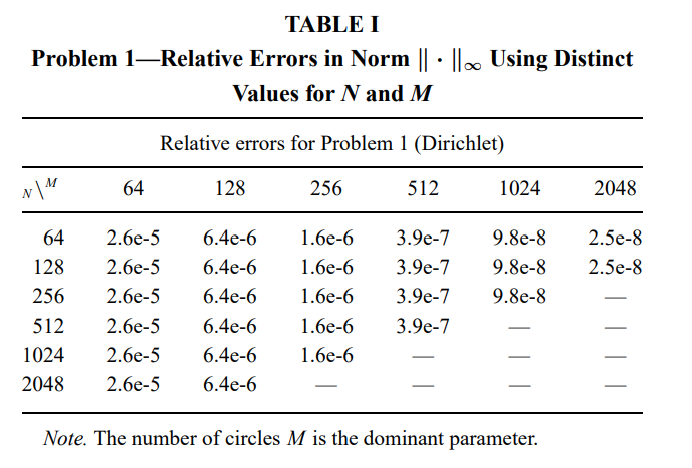

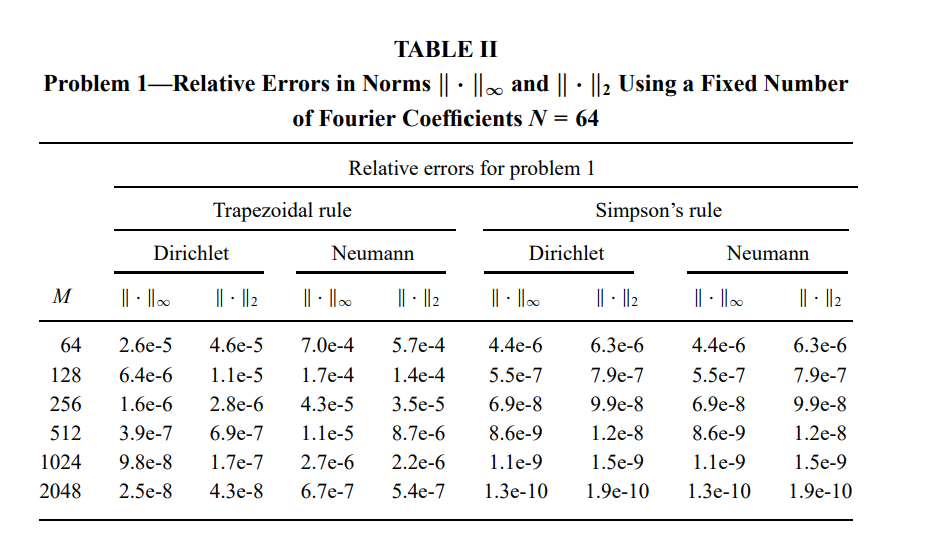